In [1]:
# Import modules

from IPython.display import Image
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.animation import FuncAnimation
import pandas as pd
import numpy as np

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# Enable interactive plot
%matplotlib notebook
%matplotlib notebook

import subprocess
import sys

# Import PySwarms
import pyswarms as ps
from pyswarms.utils.functions import single_obj as fx
from pyswarms.utils.plotters import (plot_cost_history, plot_contour, plot_surface)
from pyswarms.utils.plotters.formatters import Mesher

global particle_number
particle_number=0

from math import floor

import random

## Load the goal data

In [2]:
push_data = pd.read_csv('PushData.csv',sep=";")[['MaxForce', 'PerturbationDuration','Final_CoM_x']]
push_data.head()

,MaxForce,PerturbationDuration,Final_CoM_x
0,78.075649,0.875,-0.456892
1,72.194312,0.825,-0.354812
2,60.788209,1.030,-0.335891
3,71.539533,0.860,-0.293160
4,44.182392,0.850,-0.088240


## Fonction evaluant la stabilité du CoM en fonction des poids kd,kp

In [7]:
def weight_impact_function(kd1,kd2,kd3,kd4,kd5,kd6,kd7,kd8,kd9,kd10,kd11,kd12,kd13,kd14,kd15,kd16,kd17,kd18,kp1,kp2,kp3,kp4,kp5,kp6,kp7,kp8,kp9,kp10,kp11,kp12,kp13,kp14,kp15,kp16,kp17,kp18,force,time):
   
    kds = kd1,kd2,kd3,kd4,kd5,kd6,kd7,kd8,kd9,kd10,kd11,kd12,kd13,kd14,kd15,kd16,kd17,kd18
    kps = kp1,kp2,kp3,kp4,kp5,kp6,kp7,kp8,kp9,kp10,kp11,kp12,kp13,kp14,kp15,kp16,kp17,kp18
    
    f = open("input.txt", "w")
    f.write(('\n'.join(str(kds[i]) + " "+ str(kps[i]) for i in range(18))).replace("[","").replace("]",""))
    f.write("\n" + str(force) + " " + str(time) +"\n")
    f.close()

    subprocess.check_call(['../../bin/App_BulletExampleBrowser_vs2010_x64_debug.exe'])

    donnee_1 = pd.read_csv('output.txt', sep=" ")
    
    result = donnee_1["Z"].iat[-1]
    return result


def all_particles(kd1,kd2,kd3,kd4,kd5,kd6,kd7,kd8,kd9,kd10,kd11,kd12,kd13,kd14,kd15,kd16,kd17,kd18,kp2,kp3,kp4,kp5,kp6,kp7,kp8,kp9,kp10,kp11,kp12,kp13,kp14,kp15,kp16,kp17,kp18,force,time):
    result =[0,0]
    
    
    for j in range(5):
        current_test = push_data.iloc[random.randint(0,len(push_data)-1)].to_numpy()
        print(current_test)
        for i in range(2):
            temp_kd1 = kd1[i][0]
            temp_kp1 = kd1[i][1]
            temp = abs(abs(current_test[2])+weight_impact_function(temp_kd1,kd2,kd3,kd4,kd5,kd6,kd7,kd8,kd9,kd10,kd11,kd12,kd13,kd14,kd15,kd16,kd17,kd18,temp_kp1,kp2,kp3,kp4,kp5,kp6,kp7,kp8,kp9,kp10,kp11,kp12,kp13,kp14,kp15,kp16,kp17,kp18,current_test[0],current_test[1]))
            result[i] = result[i] + temp
            print("Diff "+ str(i) +" : " + str(abs(current_test[2])) + " - " + str(temp-abs(current_test[2])) + " -> " + str(temp) +"\n")
    
    print(result)
    return result
        
        

## Lancer la fonction une fois

In [4]:
kds = -1200, 0, -900, -900, -20, -20, -900, -900, -20, -20, -20, -20, -1200, -1200, -20, -10, -20, -10
kps = -10,0,-10, -10, -1, -1, -10, -10, -1.5, -1.5, -1.5, -1.5, -10, -10, -1, 0, -1, 0

result = weight_impact_function(-1200, 0, -900, -900, -20, -20, -900, -900, -20, -20, -20, -20, -1200, -1200, -20, -10, -20, -10,-10,0,-10, -10, -1, -1, -10, -10, -1.5, -1.5, -1.5, -1.5, -10, -10, -1, 0, -1, 0, 36,0.55)
print(result)
##donnee_1.head()

-0.445015


## Optimiser

In [13]:
kwargs = { "kd2":0, "kd3":-900, "kd4":-900, "kd5":-20, "kd6":-20, "kd7":-900, "kd8":-900, "kd9":-20, "kd10":-20, "kd11":-20, "kd12":-20, "kd13":-1200, "kd14":-1200, "kd15":-20, "kd16":-10, "kd17":-20, "kd18":-10,"kp2":0,"kp3":-10, "kp4":-10, "kp5":-1, "kp6":-1, "kp7":-10, "kp8":-10, "kp9":-1.5, "kp10":-1.5, "kp11":-1.5, "kp12":-1.5, "kp13":-20, "kp14":-20, "kp15":-1, "kp16":0, "kp17":-1, "kp18":0,"force":36,"time":0.55}
max_bound = np.array([-1100,-15])
min_bound = np.array([-1300,-25])
bounds = (min_bound, max_bound)
options = {'c1':1, 'c2':1, 'w':0.9}
optimizer = ps.single.GlobalBestPSO(n_particles=2, dimensions=2, options=options, bounds=bounds)
cost, pos = optimizer.optimize(all_particles, **kwargs,iters=2)

2023-01-18 14:11:31,525 - pyswarms.single.global_best - INFO - Optimize for 2 iters with {'c1': 1, 'c2': 1, 'w': 0.9}
pyswarms.single.global_best:   0%|                                                                                 |0/2

[42.02897586  0.515       0.11281189]
Diff 0 : 0.112811889168306 - 0.073313221663388 -> 0.186125110831694

Diff 1 : 0.112811889168306 - 0.10057822166338798 -> 0.21339011083169399

[6.20469943e+01 8.30000000e-01 1.72299156e-02]
Diff 0 : 0.0172299155591482 - 0.23218416888170357 -> 0.24941408444085178

Diff 1 : 0.0172299155591482 - 0.23187116888170356 -> 0.24910108444085177

[61.4301488   0.645      -0.09962059]
Diff 0 : 0.0996205860947807 - -0.04696017218956139 -> 0.052660413905219305

Diff 1 : 0.0996205860947807 - 0.026349827810438625 -> 0.12597041390521932

[8.43205606e+01 7.75000000e-01 4.83075859e-02]
Diff 0 : 0.0483075859494413 - 0.37344782810111743 -> 0.4217554140505587

Diff 1 : 0.0483075859494413 - 0.3631888281011174 -> 0.4114964140505587

[5.41995706e+01 5.30000000e-01 7.53987912e-03]
Diff 0 : 0.0075398791214289 - 0.3156532417571422 -> 0.3231931208785711



pyswarms.single.global_best:  50%|████████████████████████████████▌                                |1/2, best_cost=1.23

Diff 1 : 0.0075398791214289 - 0.29125124175714223 -> 0.2987911208785711

[1.2331481441068948, 1.298749144106895]
[67.01385891  0.755       0.37792726]
Diff 0 : 0.37792725923682 - -0.282108 -> 0.09581925923682



pyswarms.single.global_best:  50%|████████████████████████████████▌                                |1/2, best_cost=1.23


KeyboardInterrupt: 

## Visualiser l'optimisation

<IPython.core.display.Javascript object>


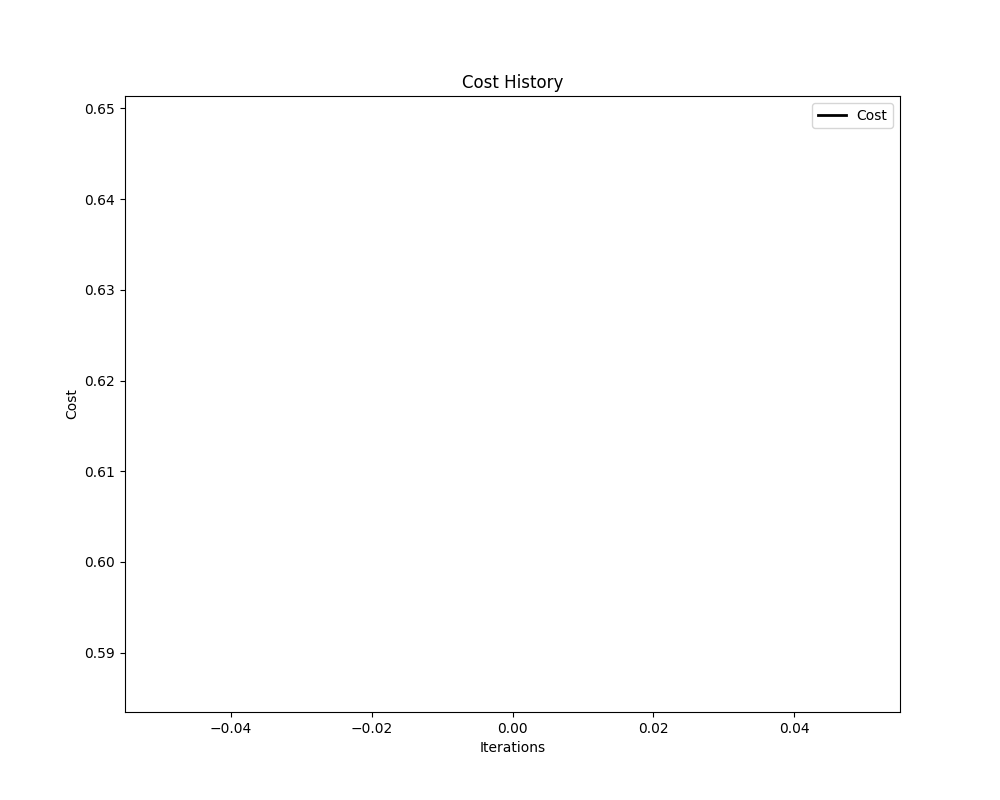

In [10]:
plot_cost_history(cost_history=optimizer.cost_history)
plt.show()

In [11]:

# Make animation
myList= optimizer.pos_history
liste = [x for x in optimizer.pos_history]

#print(liste)

#aimation = plot_contour(pos_history=liste,title='Yay')

In [ ]:


itera=50
partic=20

interp=30

x = []
y = []
for i in range(itera):
        for j in range(partic):
            x.append(liste[i][j][0])
            y.append(liste[i][j][1])   
            
            

fig, ax = plt.subplots()
points, = ax.plot(x, y, marker='o', linestyle='None')

 
            
progress = 1

def animate(frame_num):
    plt.cla()
    ax.set_xlabel('Valeur de Kp')
    ax.set_ylabel('Valeur de Kd')
    ax.set_title('Swarm Optimisation')
    
    
    ax.set_xlim(-1300,-1100)
    ax.set_ylim(-25,-15)
    
    x=[]
    y=[]
    for j in range(partic):
        x.append(liste[floor(frame_num/interp)][j][0])
        y.append(liste[floor(frame_num/interp)][j][1])
        
        if(floor(frame_num/interp) < itera):
            x[j] = [(1-(frame_num%interp * 1/interp)) * x[j] + frame_num%interp * 1/interp * liste[floor(frame_num/interp)+1][j][0]]
            y[j] = [(1-(frame_num%interp * 1/interp)) * y[j] + frame_num%interp * 1/interp * liste[floor(frame_num/interp)+1][j][1]]

    points, = ax.plot(x, y, marker='o', linestyle='None')
    
    points.set_data((x,y))
    
    return points

anim = FuncAnimation(fig, animate, frames=itera*interp, interval=5, repeat=False)
plt.show()

In [31]:
# Enables us to view it in a Jupyter notebook
anim.save('plot0.gif', writer='imagemagick', fps=30)
Image(url='plot0.gif')

2023-01-11 10:02:36,438 - matplotlib.animation - WARNING - MovieWriter imagemagick unavailable; using Pillow instead.
2023-01-11 10:02:36,439 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.PillowWriter'>


IndexError: list index out of range

## Visualiser données

In [38]:
c1x=donnee_1["c1x"].to_numpy()
c1z=donnee_1["c1z"].to_numpy()
c2x=donnee_1["c2x"].to_numpy()
c2z=donnee_1["c2z"].to_numpy()
c3x=donnee_1["c3x"].to_numpy()
c3z=donnee_1["c3z"].to_numpy()
c4x=donnee_1["c4x"].to_numpy()
c4z=donnee_1["c4z"].to_numpy()
c5x=donnee_1["c5x"].to_numpy()
c5z=donnee_1["c5z"].to_numpy()
c6x=donnee_1["c6x"].to_numpy()
c6z=donnee_1["c6z"].to_numpy()
c7x=donnee_1["c7x"].to_numpy()
c7z=donnee_1["c7z"].to_numpy()
c8x=donnee_1["c8x"].to_numpy()
c8z=donnee_1["c8z"].to_numpy()
X=donnee_1["X"].to_numpy()
Z=donnee_1["Z"].to_numpy()
vX=donnee_1["vX"].to_numpy()
vZ=donnee_1["vZ"].to_numpy()

x = [0,0,0,0,0,0,0,0,0]
y = [0,0,0,0,0,0,0,0,0]
fig, ax = plt.subplots()
points, = ax.plot(x, y, marker='o', linestyle='None')




progress = 1

def animate(frame_num):
    plt.cla()
    ax.set_xlabel('Coordonnée X')
    ax.set_ylabel('Coordonnée Z')
    ax.set_title('Position du COM')
    x = [0,0,0,0,0,0,0,0,0]
    y = [0,0,0,0,0,0,0,0,0]
    points, = ax.plot(x, y, marker='o', linestyle='None')

    ax.set_xlim(-1,1)
    ax.set_ylim(-2,2)
    x=[c1x[frame_num],c2x[frame_num],c3x[frame_num],c4x[frame_num],c5x[frame_num],c6x[frame_num],c7x[frame_num],c8x[frame_num],X[frame_num]]
    y=[c1z[frame_num],c2z[frame_num],c3z[frame_num],c4z[frame_num],c5z[frame_num],c6z[frame_num],c7z[frame_num],c8z[frame_num],Z[frame_num]]
    points.set_data((x,y))
    
    plt.plot([c1x[frame_num],c2x[frame_num],c4x[frame_num],c3x[frame_num],c1x[frame_num]],
             [c1z[frame_num],c2z[frame_num],c4z[frame_num],c3z[frame_num],c1z[frame_num]], 'o', linestyle="-", color='red')
    
    plt.plot([c5x[frame_num],c6x[frame_num],c8x[frame_num],c7x[frame_num],c5x[frame_num]],
             [c5z[frame_num],c6z[frame_num],c8z[frame_num],c7z[frame_num],c5z[frame_num]], 'o', linestyle="-", color='orange')
    
    plt.plot([X[frame_num],X[frame_num]+vX[frame_num]],
             [Z[frame_num],Z[frame_num]+vZ[frame_num]], linestyle="-.", color='blue')
    
    
    return points

anim = FuncAnimation(fig, animate, frames=len(donnee_1), interval=5, repeat=True)
plt.show()



NameError: name 'donnee_1' is not defined

83.03144066280001


In [40]:
import matplotlib.animation as animation

f = "animation.gif" 
writergif = animation.PillowWriter(fps=30) 
anim.save(f, writer=writergif)

KeyboardInterrupt: 